# EDA e Baselines

Notebook para analisar o dataset Telco Customer Churn, gerar graficos exploratorios e executar os primeiros modelos de referencia.

## Objetivos

- Carregar a base original.
- Verificar dimensoes, tipos e distribuicao da variavel alvo.
- Limpar `TotalCharges` e converter `Churn` para binario.
- Gerar graficos de EDA para entender padroes de churn.
- Criar baselines com DummyClassifier e Regressao Logistica.
- Comparar metricas dos baselines.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Permite executar o notebook tanto da raiz do repo quanto da pasta notebooks/.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT / "src"))

from telco_churn_mlops.baselines import run_baselines
from telco_churn_mlops.config import RAW_DATA_FILE
from telco_churn_mlops.data import clean_telco_data, summarize_dataset

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

## Carga dos Dados

A base original fica em `data/raw/`. Essa pasta e local e nao deve ser versionada com os dados completos.

In [2]:
raw_df = pd.read_csv(RAW_DATA_FILE)
raw_df.shape

(7043, 21)

In [3]:
raw_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
raw_df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

## Limpeza

A coluna `TotalCharges` aparece como texto. Ela sera convertida para numero; linhas sem valor numerico valido serao removidas.

In [5]:
clean_df = clean_telco_data(raw_df)
clean_df["ChurnBinary"] = clean_df["Churn"]
clean_df["ChurnLabel"] = clean_df["ChurnBinary"].map({0: "No", 1: "Yes"})
summarize_dataset(clean_df.drop(columns=["ChurnLabel"]))

DatasetSummary(rows=7032, columns=22, churn_rate=0.26578498293515357, positive_count=1869, negative_count=5163)

## Distribuicao da Variavel Alvo

Antes de treinar modelos, precisamos entender se a classe alvo esta balanceada. Neste problema, clientes sem churn sao maioria.

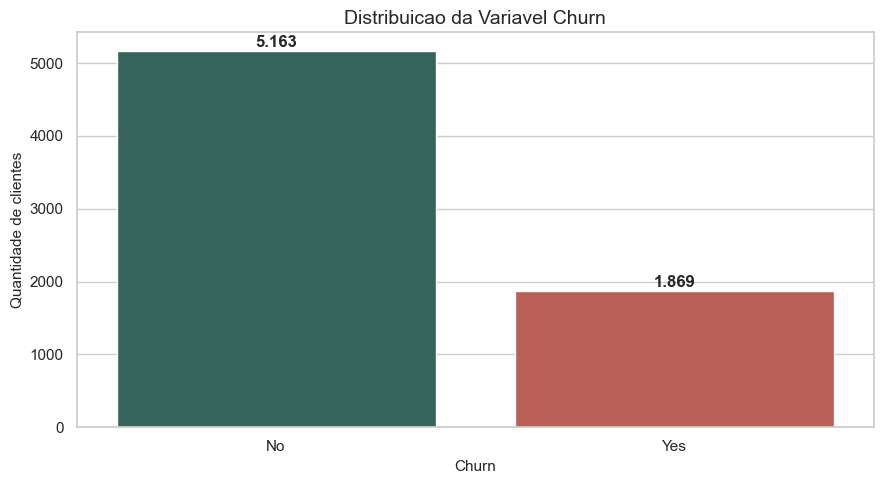

In [6]:
palette = {"No": "#2F6B5F", "Yes": "#C85146"}
counts = clean_df["ChurnLabel"].value_counts().reindex(["No", "Yes"])

fig, ax = plt.subplots()
sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette=palette, legend=False, ax=ax)
ax.set_title("Distribuicao da Variavel Churn")
ax.set_xlabel("Churn")
ax.set_ylabel("Quantidade de clientes")
for index, value in enumerate(counts.values):
    ax.text(index, value + 60, f"{value:,}".replace(",", "."), ha="center", fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "01_churn_distribution.png", dpi=160)
fig

## Churn por Tipo de Contrato

Contratos mensais costumam ter maior risco de churn porque o cliente tem menos barreira para cancelar.

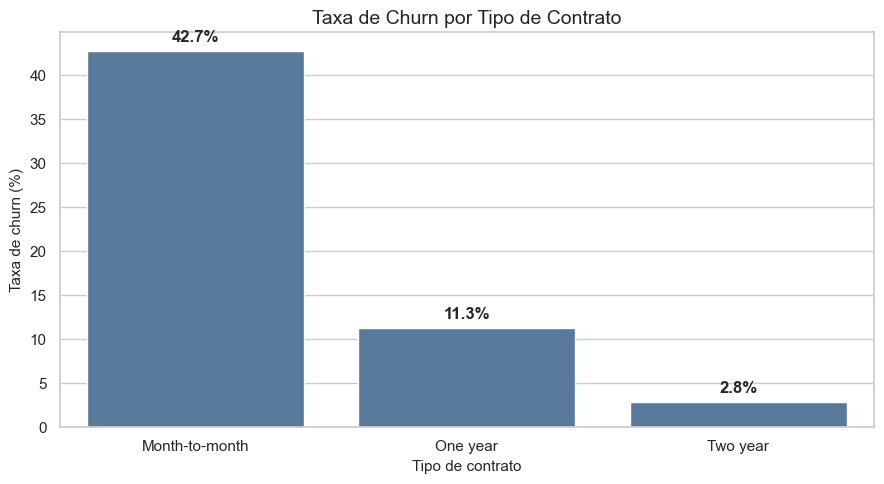

In [7]:
contract_rate = clean_df.groupby("Contract", as_index=False)["ChurnBinary"].mean()
contract_rate["ChurnBinary"] *= 100

fig, ax = plt.subplots()
sns.barplot(data=contract_rate, x="Contract", y="ChurnBinary", color="#4C78A8", ax=ax)
ax.set_title("Taxa de Churn por Tipo de Contrato")
ax.set_xlabel("Tipo de contrato")
ax.set_ylabel("Taxa de churn (%)")
for index, value in enumerate(contract_rate["ChurnBinary"]):
    ax.text(index, value + 1, f"{value:.1f}%", ha="center", fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_churn_by_contract.png", dpi=160)
fig

## Churn por Metodo de Pagamento

O metodo de pagamento pode indicar perfis de relacionamento diferentes com a operadora.

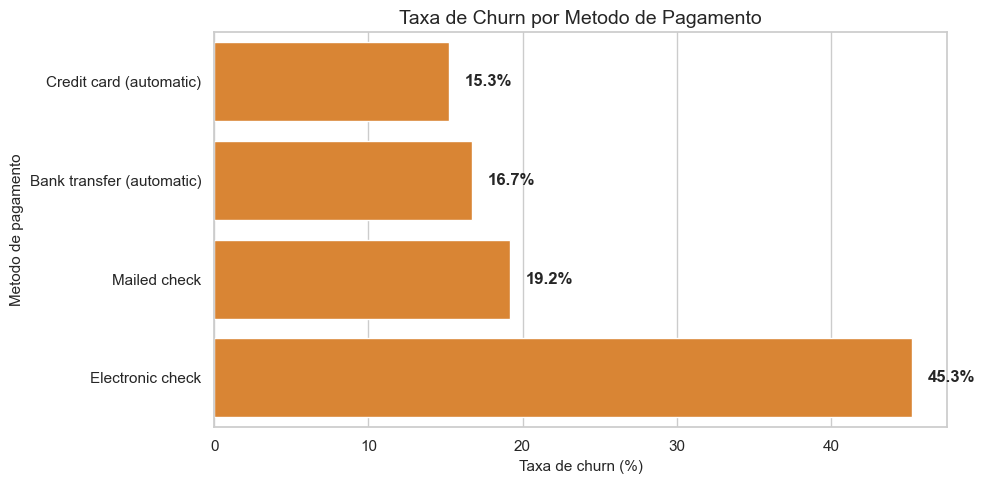

In [8]:
payment_rate = clean_df.groupby("PaymentMethod", as_index=False)["ChurnBinary"].mean()
payment_rate["ChurnBinary"] *= 100
payment_rate = payment_rate.sort_values("ChurnBinary", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=payment_rate, y="PaymentMethod", x="ChurnBinary", color="#F58518", ax=ax)
ax.set_title("Taxa de Churn por Metodo de Pagamento")
ax.set_xlabel("Taxa de churn (%)")
ax.set_ylabel("Metodo de pagamento")
for index, value in enumerate(payment_rate["ChurnBinary"]):
    ax.text(value + 1, index, f"{value:.1f}%", va="center", fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "03_churn_by_payment_method.png", dpi=160)
fig

## Tenure por Churn

`tenure` representa tempo de permanencia. Clientes mais novos podem ter comportamento de churn diferente de clientes antigos.

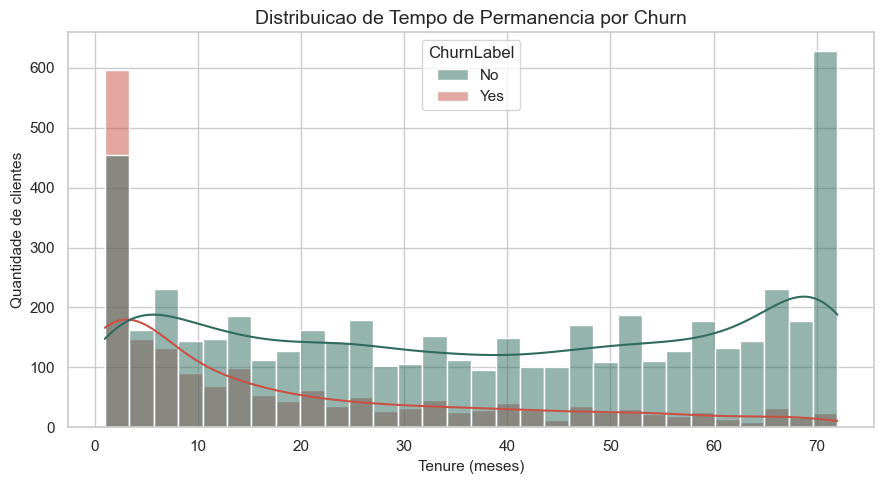

In [9]:
fig, ax = plt.subplots()
sns.histplot(
    data=clean_df,
    x="tenure",
    hue="ChurnLabel",
    hue_order=["No", "Yes"],
    bins=30,
    kde=True,
    palette=palette,
    ax=ax,
)
ax.set_title("Distribuicao de Tempo de Permanencia por Churn")
ax.set_xlabel("Tenure (meses)")
ax.set_ylabel("Quantidade de clientes")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "04_tenure_distribution_by_churn.png", dpi=160)
fig

## MonthlyCharges por Churn

A distribuicao de mensalidade ajuda a entender se clientes com churn pagam valores diferentes dos demais.

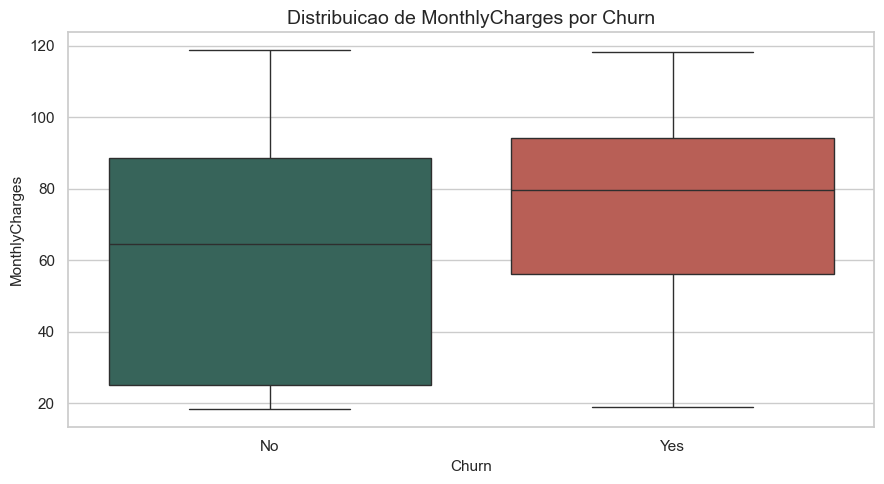

In [10]:
fig, ax = plt.subplots()
sns.boxplot(
    data=clean_df,
    x="ChurnLabel",
    y="MonthlyCharges",
    order=["No", "Yes"],
    hue="ChurnLabel",
    palette=palette,
    legend=False,
    ax=ax,
)
ax.set_title("Distribuicao de MonthlyCharges por Churn")
ax.set_xlabel("Churn")
ax.set_ylabel("MonthlyCharges")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "05_monthly_charges_by_churn.png", dpi=160)
fig

## Baselines

O primeiro baseline usa a classe majoritaria. O segundo usa Regressao Logistica com peso balanceado para lidar com o desbalanceamento da classe alvo.

In [11]:
results = run_baselines()
results

{'dataset': {'rows_after_cleaning': 7032,
  'columns': 21,
  'churn_rate': 0.26578498293515357,
  'positive_count': 1869,
  'negative_count': 5163,
  'train_rows': 5625,
  'test_rows': 1407,
  'random_state': 42},
 'models': {'dummy_most_frequent': {'accuracy': 0.7341862117981521,
   'roc_auc': 0.5,
   'f1': 0.0,
   'precision': 0.0,
   'recall': 0.0,
   'confusion_matrix': [[1033, 0], [374, 0]]},
  'logistic_regression_balanced': {'accuracy': 0.7256574271499645,
   'roc_auc': 0.8351344145860403,
   'f1': 0.6069246435845214,
   'precision': 0.4901315789473684,
   'recall': 0.7967914438502673,
   'confusion_matrix': [[723, 310], [76, 298]]}}}

## Matriz de Confusao

A matriz de confusao mostra acertos e erros do modelo. Para churn, falsos negativos sao clientes que cancelaram mas o modelo nao identificou.

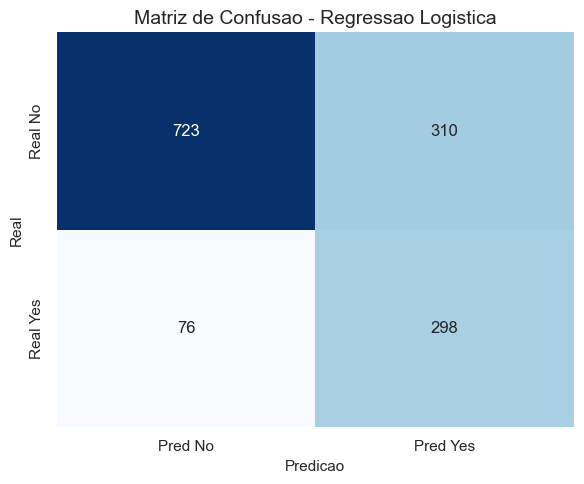

In [12]:
confusion = results["models"]["logistic_regression_balanced"]["confusion_matrix"]
confusion_df = pd.DataFrame(
    confusion,
    index=["Real No", "Real Yes"],
    columns=["Pred No", "Pred Yes"],
)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(confusion_df, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_title("Matriz de Confusao - Regressao Logistica")
ax.set_xlabel("Predicao")
ax.set_ylabel("Real")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "06_confusion_matrix_logistic_regression.png", dpi=160)
fig

## Comparacao de Metricas

A comparacao mostra por que accuracy sozinha nao e suficiente em uma base desbalanceada.

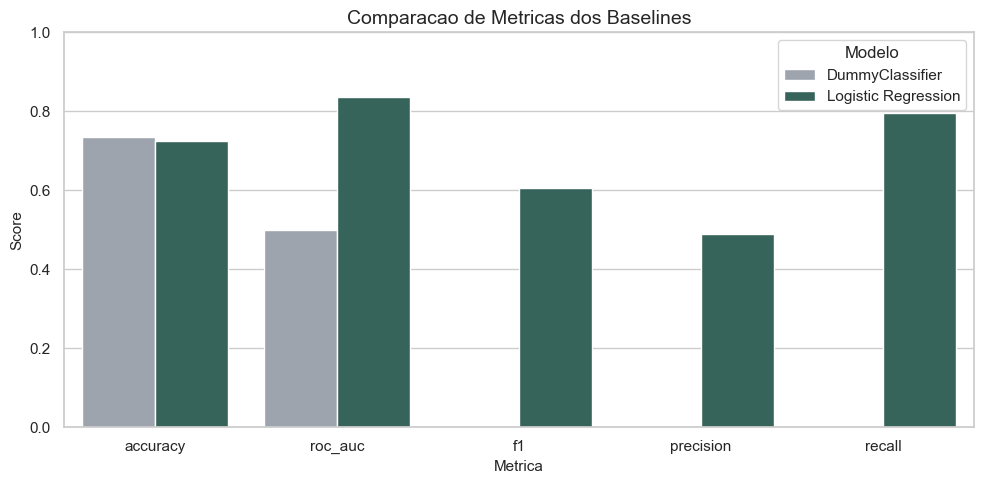

In [13]:
metric_names = ["accuracy", "roc_auc", "f1", "precision", "recall"]
metrics = pd.DataFrame(
    [
        {
            "metric": metric,
            "DummyClassifier": results["models"]["dummy_most_frequent"][metric],
            "Logistic Regression": results["models"]["logistic_regression_balanced"][metric],
        }
        for metric in metric_names
    ]
)
metrics_long = metrics.melt(id_vars="metric", var_name="model", value_name="score")

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=metrics_long,
    x="metric",
    y="score",
    hue="model",
    palette=["#9CA3AF", "#2F6B5F"],
    ax=ax,
)
ax.set_title("Comparacao de Metricas dos Baselines")
ax.set_xlabel("Metrica")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.0)
ax.legend(title="Modelo")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "07_baseline_metrics_comparison.png", dpi=160)
fig

## Manifesto dos Graficos

Esta celula registra quais graficos foram gerados localmente em `reports/figures/`.

In [14]:
manifest = {
    "figures": sorted(path.name for path in FIGURES_DIR.glob("*.png")),
    "notes": "Graficos gerados localmente pelo notebook de EDA.",
}
(FIGURES_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")
manifest

{'figures': ['01_churn_distribution.png',
  '02_churn_by_contract.png',
  '03_churn_by_payment_method.png',
  '04_tenure_distribution_by_churn.png',
  '05_monthly_charges_by_churn.png',
  '06_confusion_matrix_logistic_regression.png',
  '07_baseline_metrics_comparison.png'],
 'notes': 'Graficos gerados localmente pelo notebook de EDA.'}